# Marketing Campaign Analysis
## Phase 6 — Market basket analysis

**Data source:** spending table in marketing_db (PostgreSQL)
**Goal:** Identify which product categories tend to be purchased by the same customers, and how those patterns differ across CLV tiers.

### Methodology note — important
Classical market basket analysis (Apriori, FP-Growth) is designed for **transaction-level data** — one row per shopping trip listing the items in it. The spending data we have is the **aggregate 2-year spend per customer per category** — six dollar amounts per customer. There are no individual transactions to mine.

A naive translation ("customer spent > $0 on wines" = wines in basket) breaks the analysis: over 2 years almost every customer buys at least a little of almost every category, and Apriori would report that essentially every pair co-occurs. The output would be technically valid and analytically useless.

**What this phase does instead.** We convert continuous spend into a binary "above-median buyer" signal per category: a customer is treated as a buyer of category X if they spent above the median for that category over the 2-year window. This gives a 50/50 split per category and lets Apriori surface meaningful **purchasing affinities** — which categories tend to share their above-average buyers.

The output answers a slightly different question than "which items appear in the same basket": it answers *"which categories tend to attract the same customer"*, which is what's actually actionable for cross-sell and bundle design.

### Evaluation metrics
- **Support** — fraction of customers who are above-median in both categories of a rule
- **Confidence** — P(above-median in Y | above-median in X)
- **Lift** — confidence divided by P(above-median in Y). Lift > 1 means stronger-than-chance co-occurrence. **Lift is the primary metric** because it controls for category frequency.

### CLV-tier breakdown
We run the analysis overall and then within each Phase 4 CLV tier (Low / Mid / High value). Phase 3 showed that catalog is the "luxury channel" — we expect basket patterns to differ sharply between low and high CLV tiers.

---
## 1. Import libraries & connect to database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import getpass
import warnings
from pathlib import Path

from sqlalchemy import create_engine, text

# mlxtend — the standard Apriori / FP-Growth / association rules toolkit
# Install once via: pip install mlxtend
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
DOCS_PATH      = str(PROJECT_ROOT / 'docs')
SQL_PATH       = str(PROJECT_ROOT / 'sql' / 'queries')
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(DOCS_PATH, exist_ok=True)
os.makedirs(SQL_PATH, exist_ok=True)

# PostgreSQL local trust auth
username = getpass.getuser()
engine   = create_engine(
    f'postgresql+psycopg2://{username}@localhost:5432/marketing_db',
    future=True
)

def run_query(sql, name=None):
    if name:
        with open(os.path.join(SQL_PATH, f'{name}.sql'), 'w') as f:
            f.write(sql.strip())
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

test = run_query('SELECT COUNT(*) AS n FROM customers')
print(f'Connected ✅ — {test["n"].values[0]:,} customers in database')

Connected ✅ — 2,212 customers in database


---
## 2. Pull category spend and CLV tier in a single query
Join the spending and customer tables, derive the CLV tier with `NTILE(3)` (same logic Phase 4 uses), and return one row per customer with the six category spends.

In [2]:
sql_spend_tiers = '''
WITH customer_tiers AS (
    SELECT
        s.customer_id,
        s.mnt_wines,
        s.mnt_fruits,
        s.mnt_meat,
        s.mnt_fish,
        s.mnt_sweets,
        s.mnt_gold,
        s.total_spend,
        NTILE(3) OVER (ORDER BY s.total_spend) AS clv_tier_num
    FROM spending s
)
SELECT
    customer_id,
    mnt_wines, mnt_fruits, mnt_meat, mnt_fish, mnt_sweets, mnt_gold,
    total_spend,
    CASE clv_tier_num
        WHEN 1 THEN 'Low value'
        WHEN 2 THEN 'Mid value'
        WHEN 3 THEN 'High value'
    END AS clv_tier
FROM customer_tiers
'''

spend_df = run_query(sql_spend_tiers, 'mba_spend_with_tiers')

print(f'Customers: {len(spend_df):,}')
print(f'\nSpend column medians (used as binary threshold):')
spend_cols = ['mnt_wines', 'mnt_fruits', 'mnt_meat',
              'mnt_fish', 'mnt_sweets', 'mnt_gold']
for c in spend_cols:
    print(f'  {c:<14} ${spend_df[c].median():,.0f}')

print(f'\nCLV tier counts:')
print(spend_df['clv_tier'].value_counts().to_string())

Customers: 2,212

Spend column medians (used as binary threshold):
  mnt_wines      $176
  mnt_fruits     $8
  mnt_meat       $68
  mnt_fish       $12
  mnt_sweets     $8
  mnt_gold       $24

CLV tier counts:
clv_tier
Low value     738
Mid value     737
High value    737


---
## 3. Build the binary purchase-affinity matrix
For each customer and each category, mark 1 if the customer spent above the category median, 0 otherwise. The result is a sparse-ish 0/1 matrix that Apriori can consume directly. We give the columns readable names — these will appear in the output rules.

In [3]:
# Pretty category labels
category_labels = {
    'mnt_wines':  'Wines',
    'mnt_fruits': 'Fruits',
    'mnt_meat':   'Meat',
    'mnt_fish':   'Fish',
    'mnt_sweets': 'Sweets',
    'mnt_gold':   'Gold',
}

# Build the binary above-median matrix
basket = pd.DataFrame({'customer_id': spend_df['customer_id'],
                       'clv_tier':    spend_df['clv_tier']})

for raw_col, label in category_labels.items():
    threshold = spend_df[raw_col].median()
    basket[label] = (spend_df[raw_col] > threshold).astype(int)

# Sanity check: each column should be roughly 50% ones since we used the median
print('Share of customers above category median (should be ~50% per column):')
for label in category_labels.values():
    pct = basket[label].mean() * 100
    print(f'  {label:<8} {pct:.1f}%')

# Quick look at the basket
print('\nBasket preview:')
print(basket.head(6).to_string(index=False))

Share of customers above category median (should be ~50% per column):
  Wines    50.0%
  Fruits   49.1%
  Meat     49.6%
  Fish     49.1%
  Sweets   49.5%
  Gold     50.0%

Basket preview:
 customer_id  clv_tier  Wines  Fruits  Meat  Fish  Sweets  Gold
       11110 Low value      0       0     0     0       0     0
        5555 Low value      0       0     0     0       0     0
        3955 Low value      0       0     0     0       0     0
       10104 Low value      0       0     0     0       0     0
        6862 Low value      0       0     0     0       0     0
        5824 Low value      0       0     0     0       0     0


---
## 4. Apriori — overall purchasing affinities
Run Apriori on the full customer base with a minimum support of 10%. This finds all itemsets where at least 10% of customers are above-median in **all** items of the set. Lower support thresholds produce more rules but also more noise — 10% is a defensible floor for a 2,212-customer base.

In [4]:
# Apriori expects a boolean DataFrame of items only — drop the metadata columns
items_only = basket.drop(columns=['customer_id', 'clv_tier']).astype(bool)

# Find frequent itemsets — minimum support = 10% of customers
frequent_itemsets = apriori(items_only, min_support=0.10, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f'Frequent itemsets found (min support = 10%): {len(frequent_itemsets)}')
print()
print('Top 15 frequent itemsets:')
display_fi = frequent_itemsets.copy()
display_fi['itemsets'] = display_fi['itemsets'].apply(lambda s: ', '.join(sorted(s)))
print(display_fi.head(15).to_string(index=False))

Frequent itemsets found (min support = 10%): 63

Top 15 frequent itemsets:
 support       itemsets
0.500000          Wines
0.500000           Gold
0.496383           Meat
0.495479         Sweets
0.491410           Fish
0.490958         Fruits
0.428571    Meat, Wines
0.408680     Fish, Meat
0.406872   Meat, Sweets
0.405063   Fruits, Meat
0.404159 Fruits, Sweets
0.403255   Fish, Fruits
0.401447   Fish, Sweets
0.386076     Gold, Meat
0.377034    Gold, Wines


---
## 5. Association rules — overall
Convert frequent itemsets into rules and filter by:
- **Lift ≥ 1.2** — at least 20% stronger than chance co-occurrence
- **Confidence ≥ 0.5** — knowing the antecedent gives a coin-flip-or-better chance of the consequent
- **Support ≥ 0.1** — meaningful frequency

Rules with lift < 1 are anti-associations (categories whose above-median buyers don't overlap) — we report a few of those separately because they're useful signal too.

In [5]:
rules_all = association_rules(
    frequent_itemsets, metric='lift', min_threshold=1.2
)
rules_all = rules_all[
    (rules_all['confidence'] >= 0.5) & (rules_all['support'] >= 0.10)
].copy()

# Convert frozensets to readable strings for display
def fmt_set(s):
    return ', '.join(sorted(s))
rules_all['antecedents_str'] = rules_all['antecedents'].apply(fmt_set)
rules_all['consequents_str'] = rules_all['consequents'].apply(fmt_set)

# Sort by lift first (strength of association), then by support (prevalence)
rules_all = rules_all.sort_values(['lift', 'support'], ascending=[False, False])

display_cols = ['antecedents_str', 'consequents_str',
                'support', 'confidence', 'lift']
print(f'Association rules found: {len(rules_all)}')
print()
print('Top 15 rules by lift:')
print(rules_all[display_cols].head(15).round(3).to_string(index=False))

Association rules found: 591

Top 15 rules by lift:
            antecedents_str            consequents_str  support  confidence  lift
           Fish, Gold, Meat      Fruits, Sweets, Wines     0.24       0.740 2.296
      Fruits, Sweets, Wines           Fish, Gold, Meat     0.24       0.743 2.296
         Fruits, Gold, Meat        Fish, Sweets, Wines     0.24       0.738 2.262
        Fish, Sweets, Wines         Fruits, Gold, Meat     0.24       0.734 2.262
          Fish, Gold, Wines       Fruits, Meat, Sweets     0.24       0.802 2.259
       Fruits, Meat, Sweets          Fish, Gold, Wines     0.24       0.675 2.259
         Gold, Meat, Sweets        Fish, Fruits, Wines     0.24       0.735 2.249
        Fish, Fruits, Wines         Gold, Meat, Sweets     0.24       0.733 2.249
         Fish, Fruits, Meat        Gold, Sweets, Wines     0.24       0.663 2.244
        Gold, Sweets, Wines         Fish, Fruits, Meat     0.24       0.810 2.244
 Fruits, Gold, Meat, Sweets                Fis

In [6]:
# Anti-associations — pairs that AVOID each other (lift < 1)
# Useful for cross-sell: bundling these together would underperform random pairing
anti_rules = association_rules(
    frequent_itemsets, metric='lift', min_threshold=0.0
)
anti_rules = anti_rules[
    (anti_rules['lift'] < 0.9) & (anti_rules['support'] >= 0.05)
].copy()
anti_rules['antecedents_str'] = anti_rules['antecedents'].apply(fmt_set)
anti_rules['consequents_str'] = anti_rules['consequents'].apply(fmt_set)
anti_rules = anti_rules.sort_values('lift', ascending=True)

print(f'Anti-association pairs (lift < 0.9): {len(anti_rules)}')
if len(anti_rules) > 0:
    print('\nTop 5 anti-associations (avoid bundling these):')
    print(anti_rules[display_cols].head(5).round(3).to_string(index=False))
else:
    print('No strong anti-associations found.')

Anti-association pairs (lift < 0.9): 0
No strong anti-associations found.


---
## 6. FP-Growth cross-check
Run FP-Growth as an independent algorithm and confirm it produces the same itemsets. This is a sanity check — Apriori and FP-Growth use different search strategies but should converge on identical frequent itemsets given the same data and minimum support.

In [7]:
fp_itemsets = fpgrowth(items_only, min_support=0.10, use_colnames=True)

# Compare counts
print(f'Apriori itemsets:    {len(frequent_itemsets)}')
print(f'FP-Growth itemsets:  {len(fp_itemsets)}')

# Compare the actual set contents
apriori_sets = set(frozenset(s) for s in frequent_itemsets['itemsets'])
fpgrowth_sets = set(frozenset(s) for s in fp_itemsets['itemsets'])

if apriori_sets == fpgrowth_sets:
    print('✅ Algorithms agree on every frequent itemset.')
else:
    diff_a = apriori_sets - fpgrowth_sets
    diff_b = fpgrowth_sets - apriori_sets
    print(f'⚠️  Disagreement: {len(diff_a)} only-in-Apriori, {len(diff_b)} only-in-FP-Growth.')

Apriori itemsets:    63
FP-Growth itemsets:  63
✅ Algorithms agree on every frequent itemset.


---
## 7. Visualise the strongest rules

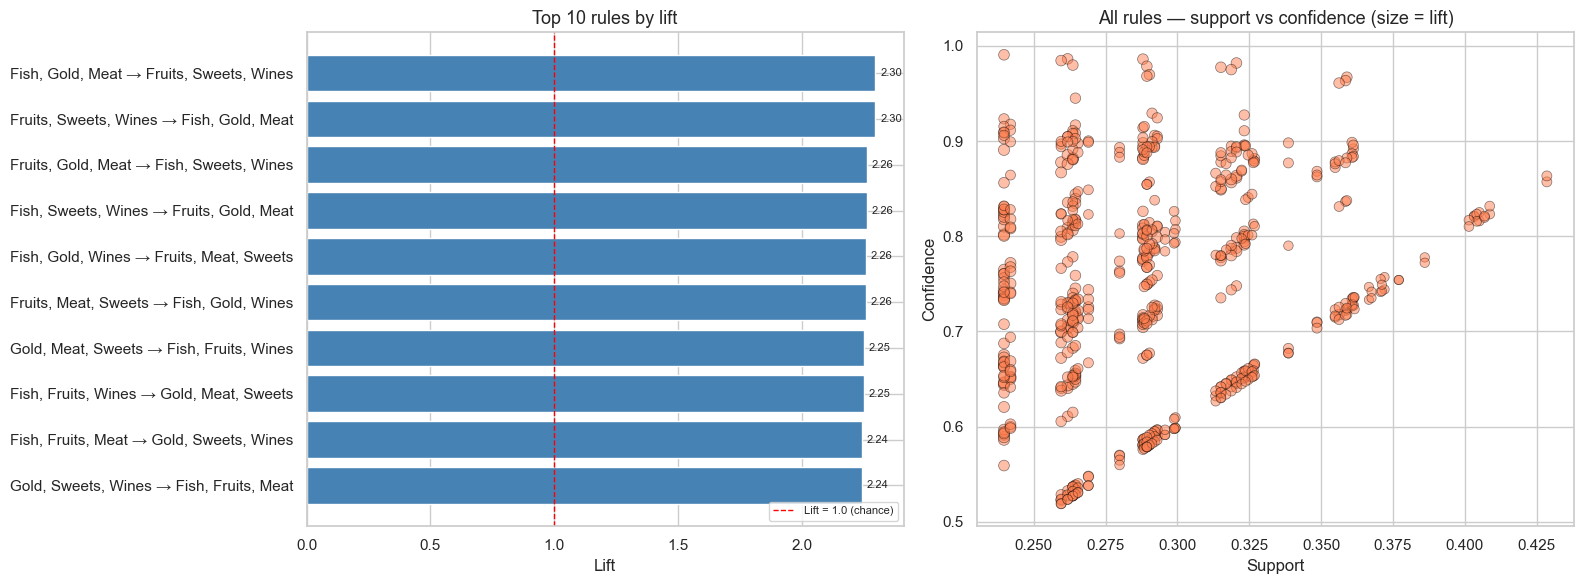

In [8]:
# Top 10 rules by lift — horizontal bar chart
top10 = rules_all.head(10).copy()
top10['rule'] = top10['antecedents_str'] + ' → ' + top10['consequents_str']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Lift
axes[0].barh(top10['rule'][::-1], top10['lift'][::-1], color='steelblue')
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Lift = 1.0 (chance)')
axes[0].set_title('Top 10 rules by lift', fontsize=13)
axes[0].set_xlabel('Lift')
axes[0].legend(loc='lower right', fontsize=8)
for i, (lift, sup) in enumerate(zip(top10['lift'][::-1], top10['support'][::-1])):
    axes[0].text(lift + 0.02, i, f'{lift:.2f}', va='center', fontsize=8)

# Right — Support vs Confidence scatter, sized by lift
axes[1].scatter(
    rules_all['support'], rules_all['confidence'],
    s=rules_all['lift'] * 30, alpha=0.5, color='coral',
    edgecolors='black', linewidths=0.5
)
axes[1].set_title('All rules — support vs confidence (size = lift)', fontsize=13)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p6_rules_overall.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Rules by CLV tier
Phase 3 showed catalog is the luxury channel — high-spending customers behave differently. This section runs Apriori within each Phase 4 CLV tier separately. Each tier has ~740 customers so the minimum support is loosened to 15% (≈110 customers per rule); the lift threshold is held at 1.2.

In [9]:
tier_results = {}
tier_min_support = 0.15  # Looser threshold for smaller tier subsets

for tier in ['Low value', 'Mid value', 'High value']:
    tier_basket = basket[basket['clv_tier'] == tier].drop(
        columns=['customer_id', 'clv_tier']
    ).astype(bool)

    # IMPORTANT: re-compute the above-median binary signal WITHIN the tier
    # so we are measuring "above-median for this tier", not the global threshold
    # (otherwise the Low tier would have almost no positives and High would have
    # almost all positives)
    tier_spend = spend_df[spend_df['clv_tier'] == tier]
    tier_basket = pd.DataFrame()
    for raw_col, label in category_labels.items():
        threshold = tier_spend[raw_col].median()
        tier_basket[label] = (tier_spend[raw_col] > threshold).astype(bool)
    tier_basket = tier_basket.reset_index(drop=True)

    itemsets = apriori(tier_basket, min_support=tier_min_support, use_colnames=True)
    if len(itemsets) == 0:
        rules = pd.DataFrame()
    else:
        rules = association_rules(itemsets, metric='lift', min_threshold=1.2)
        rules = rules[rules['confidence'] >= 0.5].copy()
        if len(rules) > 0:
            rules['antecedents_str'] = rules['antecedents'].apply(fmt_set)
            rules['consequents_str'] = rules['consequents'].apply(fmt_set)
            rules = rules.sort_values('lift', ascending=False)

    tier_results[tier] = {
        'customer_count': len(tier_spend),
        'itemsets_count': len(itemsets),
        'rules_count':    len(rules),
        'rules':          rules,
    }
    print(f'{tier:<14} customers: {len(tier_spend):>4} '
          f'itemsets: {len(itemsets):>3}  rules (lift≥1.2): {len(rules):>3}')

Low value      customers:  738 itemsets:  30  rules (lift≥1.2):  55
Mid value      customers:  737 itemsets:  43  rules (lift≥1.2): 108
High value     customers:  737 itemsets:  29  rules (lift≥1.2):  25


In [10]:
# Print top rules per tier
for tier, result in tier_results.items():
    print(f'\n{"=" * 60}')
    print(f'{tier} — top rules by lift')
    print(f'{"=" * 60}')
    if result['rules_count'] == 0:
        print('  No rules met the threshold.')
        continue
    cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
    print(result['rules'][cols].head(8).round(3).to_string(index=False))


Low value — top rules by lift
antecedents_str consequents_str  support  confidence  lift
         Fruits      Fish, Gold    0.210       0.505 1.854
     Fish, Gold          Fruits    0.210       0.771 1.854
         Fruits    Gold, Sweets    0.209       0.502 1.824
   Gold, Sweets          Fruits    0.209       0.759 1.824
           Fish    Fruits, Gold    0.210       0.529 1.799
   Fruits, Gold            Fish    0.210       0.714 1.799
         Sweets    Fruits, Gold    0.209       0.512 1.740
   Fruits, Gold          Sweets    0.209       0.710 1.740

Mid value — top rules by lift
antecedents_str consequents_str  support  confidence  lift
   Fish, Sweets    Fruits, Meat    0.214       0.610 1.873
   Fruits, Meat    Fish, Sweets    0.214       0.658 1.873
   Meat, Sweets      Fish, Gold    0.164       0.502 1.832
     Fish, Gold    Meat, Sweets    0.164       0.599 1.832
   Fruits, Gold    Meat, Sweets    0.163       0.588 1.799
     Fish, Gold    Fruits, Meat    0.160       0.584 

---
## 9. Cross-tier comparison
Which rules are unique to High value customers? Which appear across all tiers? This is the actionable output — rules that hold only for the High tier identify cross-sell patterns specific to the company's most valuable customers.

In [11]:
# Build a comparison frame — for each (antecedent → consequent) pair across tiers,
# show whether it appears at lift ≥ 1.2 in each tier
def rule_signature(row):
    return (row['antecedents_str'], row['consequents_str'])

all_rule_signatures = set()
for tier, result in tier_results.items():
    if result['rules_count'] > 0:
        for _, row in result['rules'].iterrows():
            all_rule_signatures.add(rule_signature(row))

comparison_rows = []
for ant, con in all_rule_signatures:
    row = {'antecedents': ant, 'consequents': con}
    for tier in ['Low value', 'Mid value', 'High value']:
        r = tier_results[tier]['rules']
        if len(r) > 0:
            match = r[(r['antecedents_str'] == ant) & (r['consequents_str'] == con)]
            row[f'{tier} lift'] = round(float(match.iloc[0]['lift']), 2) if len(match) else None
        else:
            row[f'{tier} lift'] = None
    comparison_rows.append(row)

compare_df = pd.DataFrame(comparison_rows)
# Order: rules with the strongest High-tier lift first
compare_df = compare_df.sort_values('High value lift', ascending=False, na_position='last')

print(f'Total unique rules across tiers: {len(compare_df)}')
print()
print('Rule comparison across CLV tiers (lift in each tier, None = below threshold):')
print(compare_df.head(20).to_string(index=False))

Total unique rules across tiers: 122

Rule comparison across CLV tiers (lift in each tier, None = below threshold):
   antecedents consequents  Low value lift  Mid value lift  High value lift
  Fruits, Gold        Fish            1.80            1.56             1.42
  Gold, Sweets        Fish            1.71            1.51             1.42
Fruits, Sweets        Fish            1.62            1.60             1.41
  Fish, Fruits      Sweets            1.62            1.60             1.40
    Fish, Gold      Fruits            1.85            1.59             1.37
  Fish, Sweets      Fruits            1.70            1.63             1.37
  Gold, Sweets      Fruits            1.82            1.55             1.36
    Gold, Meat        Fish            1.42            1.39             1.36
  Meat, Sweets        Fish            1.58            1.62             1.31
        Sweets        Fish            1.56            1.49             1.31
          Fish      Sweets            1.56      

In [12]:
# Rules that appear ONLY in the High value tier — the cross-sell signature
# of the most valuable customers
high_only = compare_df[
    compare_df['High value lift'].notna() &
    compare_df['Mid value lift'].isna() &
    compare_df['Low value lift'].isna()
]
print(f'\nRules unique to High value tier: {len(high_only)}')
if len(high_only) > 0:
    print(high_only.head(10).to_string(index=False))


Rules unique to High value tier: 0


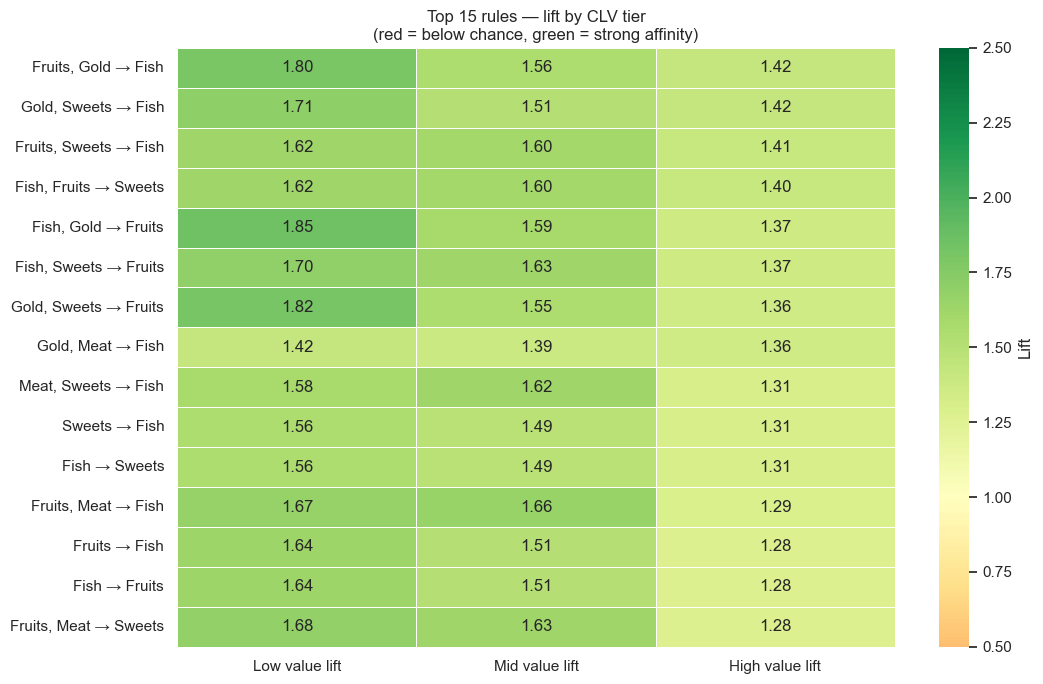

In [13]:
# Visualise the comparison — heatmap of lift values per tier
heatmap_data = compare_df.copy()
heatmap_data['rule'] = heatmap_data['antecedents'] + ' → ' + heatmap_data['consequents']
heatmap_data = heatmap_data.set_index('rule')[
    ['Low value lift', 'Mid value lift', 'High value lift']
].head(15)

plt.figure(figsize=(11, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
    center=1.0, vmin=0.5, vmax=2.5, linewidths=0.4,
    cbar_kws={'label': 'Lift'}
)
plt.title('Top 15 rules — lift by CLV tier\n(red = below chance, green = strong affinity)',
          fontsize=12)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p6_rules_by_tier_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Connect to the catalog channel finding from Phase 3
Phase 3 showed that catalog purchases are 20× more frequent among High value customers than Low value. We now check whether catalog-heavy customers also show stronger basket affinities — and if so, which categories.

In [14]:
sql_catalog = '''
SELECT
    s.customer_id,
    s.mnt_wines, s.mnt_fruits, s.mnt_meat,
    s.mnt_fish,  s.mnt_sweets, s.mnt_gold,
    ch.num_catalog_purchases
FROM spending s
JOIN channels ch ON s.customer_id = ch.customer_id
'''

catalog_df = run_query(sql_catalog, 'mba_catalog_link')

# Split customers into catalog-heavy and catalog-light using the median
cat_median = catalog_df['num_catalog_purchases'].median()
catalog_df['catalog_heavy'] = (catalog_df['num_catalog_purchases'] > cat_median).astype(int)

# Build a basket within catalog-heavy customers only
heavy = catalog_df[catalog_df['catalog_heavy'] == 1]
heavy_basket = pd.DataFrame()
for raw_col, label in category_labels.items():
    threshold = heavy[raw_col].median()
    heavy_basket[label] = (heavy[raw_col] > threshold).astype(bool)
heavy_basket = heavy_basket.reset_index(drop=True)

print(f'Catalog-heavy customers: {len(heavy):,} (above-median catalog purchases)')
print(f'Catalog-light customers: {len(catalog_df) - len(heavy):,}')

# Apriori on catalog-heavy
heavy_itemsets = apriori(heavy_basket, min_support=0.15, use_colnames=True)
if len(heavy_itemsets) > 0:
    heavy_rules = association_rules(heavy_itemsets, metric='lift', min_threshold=1.2)
    heavy_rules = heavy_rules[heavy_rules['confidence'] >= 0.5].copy()
    heavy_rules['antecedents_str'] = heavy_rules['antecedents'].apply(fmt_set)
    heavy_rules['consequents_str'] = heavy_rules['consequents'].apply(fmt_set)
    heavy_rules = heavy_rules.sort_values('lift', ascending=False)
    cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
    print(f'\nTop rules among catalog-heavy customers:')
    print(heavy_rules[cols].head(8).round(3).to_string(index=False))
else:
    print('\nNo rules found among catalog-heavy customers.')

Catalog-heavy customers: 873 (above-median catalog purchases)
Catalog-light customers: 1,339

Top rules among catalog-heavy customers:
   antecedents_str consequents_str  support  confidence  lift
      Fish, Fruits    Meat, Sweets    0.168       0.531 1.685
      Meat, Sweets    Fish, Fruits    0.168       0.535 1.685
      Fruits, Meat    Fish, Sweets    0.168       0.551 1.586
Fish, Fruits, Meat          Sweets    0.168       0.786 1.574
      Fish, Fruits          Sweets    0.246       0.776 1.554
Fish, Meat, Sweets          Fruits    0.168       0.746 1.544
        Fish, Meat  Fruits, Sweets    0.168       0.516 1.532
    Fruits, Sweets      Fish, Meat    0.168       0.500 1.532


---
## 11. Save outputs for the dashboard
Three CSVs feed the Phase 6 Tableau dashboard: the overall rules, the per-tier comparison, and the catalog-heavy rules.

In [15]:
# Strip frozenset columns before saving (Tableau can't read them)
save_cols = ['antecedents_str', 'consequents_str',
             'support', 'confidence', 'lift']

rules_all[save_cols].to_csv(
    os.path.join(PROCESSED_PATH, 'mba_rules_overall.csv'), index=False
)
compare_df.to_csv(
    os.path.join(PROCESSED_PATH, 'mba_rules_by_tier.csv'), index=False
)
if 'heavy_rules' in dir() and len(heavy_rules) > 0:
    heavy_rules[save_cols].to_csv(
        os.path.join(PROCESSED_PATH, 'mba_rules_catalog_heavy.csv'), index=False
    )

# Frequent itemsets — useful for the dashboard's "category mix" view
freq_save = frequent_itemsets.copy()
freq_save['itemsets'] = freq_save['itemsets'].apply(lambda s: ', '.join(sorted(s)))
freq_save.to_csv(
    os.path.join(PROCESSED_PATH, 'mba_frequent_itemsets.csv'), index=False
)

print('✅ mba_rules_overall.csv          saved')
print('✅ mba_rules_by_tier.csv          saved')
print('✅ mba_rules_catalog_heavy.csv    saved')
print('✅ mba_frequent_itemsets.csv      saved')

✅ mba_rules_overall.csv          saved
✅ mba_rules_by_tier.csv          saved
✅ mba_rules_catalog_heavy.csv    saved
✅ mba_frequent_itemsets.csv      saved


---
## 12. Phase 6 summary

In [16]:
# Build a few summary numbers
n_rules_overall = len(rules_all)
n_high_only     = len(high_only) if 'high_only' in dir() else 0
top_rule        = rules_all.iloc[0] if len(rules_all) > 0 else None

high_tier_rules = tier_results['High value']['rules']
low_tier_rules  = tier_results['Low value']['rules']

print('=' * 64)
print('PHASE 6 SUMMARY — MARKET BASKET ANALYSIS')
print('=' * 64)
print()
print('--- Methodology ---')
print('Definition of "buyer":     above-median spend in category over 2-year window')
print('Algorithms:                Apriori (primary), FP-Growth (cross-check)')
print('Min support / confidence:  0.10 / 0.50 overall; 0.15 / 0.50 per CLV tier')
print('Min lift threshold:        1.2 (20% above chance)')
print()
print('--- Overall results ---')
print(f'Frequent itemsets found:   {len(frequent_itemsets)}')
print(f'Association rules:         {n_rules_overall} (lift ≥ 1.2, conf ≥ 0.5)')
if top_rule is not None:
    print(f'Strongest rule:            {top_rule["antecedents_str"]} → '
          f'{top_rule["consequents_str"]} (lift {top_rule["lift"]:.2f})')
print()
print('--- Per-CLV-tier ---')
print(f'Low value tier:            {tier_results["Low value"]["rules_count"]} rules')
print(f'Mid value tier:            {tier_results["Mid value"]["rules_count"]} rules')
print(f'High value tier:           {tier_results["High value"]["rules_count"]} rules')
print(f'Rules unique to High tier: {n_high_only} (cross-sell signature of top customers)')
print()
print('--- Outputs ---')
print('  mba_rules_overall.csv')
print('  mba_rules_by_tier.csv')
print('  mba_rules_catalog_heavy.csv')
print('  mba_frequent_itemsets.csv')
print('=' * 64)
print()
print('Key takeaways for the Tableau dashboard:')
print('  • Rule strength (lift) by category pair — heatmap view')
print('  • CLV tier comparison — which patterns belong to high-value customers')
print('  • Catalog-heavy customers — confirms the Phase 3 luxury-channel finding')
print()
print('✅ Phase 6 complete. Proceed to the Tableau dashboard build.')

PHASE 6 SUMMARY — MARKET BASKET ANALYSIS

--- Methodology ---
Definition of "buyer":     above-median spend in category over 2-year window
Algorithms:                Apriori (primary), FP-Growth (cross-check)
Min support / confidence:  0.10 / 0.50 overall; 0.15 / 0.50 per CLV tier
Min lift threshold:        1.2 (20% above chance)

--- Overall results ---
Frequent itemsets found:   63
Association rules:         591 (lift ≥ 1.2, conf ≥ 0.5)
Strongest rule:            Fish, Gold, Meat → Fruits, Sweets, Wines (lift 2.30)

--- Per-CLV-tier ---
Low value tier:            55 rules
Mid value tier:            108 rules
High value tier:           25 rules
Rules unique to High tier: 0 (cross-sell signature of top customers)

--- Outputs ---
  mba_rules_overall.csv
  mba_rules_by_tier.csv
  mba_rules_catalog_heavy.csv
  mba_frequent_itemsets.csv

Key takeaways for the Tableau dashboard:
  • Rule strength (lift) by category pair — heatmap view
  • CLV tier comparison — which patterns belong to high